In [6]:
# Import EUMDAC and dependent libraries to begin
import eumdac
import datetime
import shutil
import requests
import time
import os
# Insert your personal key and secret
consumer_key = 'rM5wCB0EbwE7t8L3QU9VlpGNuRsa'
consumer_secret = 'anL3Vk6Oq7eriiifXnjmbVVR78Aa'

credentials = (consumer_key, consumer_secret)

token = eumdac.AccessToken(credentials)

print(f"This token '{token}' expires {token.expiration}")

This token 'c5eb9575-ef07-303e-a27e-620eee45145e' expires 2026-03-18 23:27:24.452060


In [7]:
datastore = eumdac.DataStore(token)

try:    
    selected_collection = datastore.get_collection('EO:EUM:DAT:MSG:HRSEVIRI')
    print(f"{selected_collection} - {selected_collection.title}")
except eumdac.datastore.DataStoreError as error:
    print(f"Error related to the data store: '{error.msg}'")
except eumdac.collection.CollectionError as error:
    print(f"Error related to the collection: '{error.msg}'")
except requests.exceptions.ConnectionError as error:
    print(f"Error related to the connection: '{error.msg}'")
except requests.exceptions.RequestException as error:
    print(f"Unexpected error: {error}")

EO:EUM:DAT:MSG:HRSEVIRI - High Rate SEVIRI Level 1.5 Image Data - MSG - 0 degree


In [9]:
selected_product = datastore.get_product(
    product_id='MSG4-SEVI-MSG15-0100-NA-20211110081242.766000000Z-NA',
    collection_id='EO:EUM:DAT:MSG:HRSEVIRI')

try:
    print(selected_product) 
except eumdac.product.ProductError as error:
    print(f"Error related to the product: '{error.msg}'")
except requests.exceptions.ConnectionError as error:
    print(f"Error related to the connection: '{error.msg}'")
except requests.exceptions.RequestException as error:
    print(f"Unexpected error: {error}")

MSG4-SEVI-MSG15-0100-NA-20211110081242.766000000Z-NA


In [10]:
for entry in selected_product.entries:
    try:
        print(entry)
    except eumdac.product.ProductError as error:
        print(f"Error related to the product: '{error.msg}'")
    except requests.exceptions.ConnectionError as error:
        print(f"Error related to the connection: '{error.msg}'")
    except requests.exceptions.RequestException as error:
        print(f"Unexpected error: {error}")

EOPMetadata.xml
MSG4-SEVI-MSG15-0100-NA-20211110081242.766000000Z-NA.nat
manifest.xml


In [11]:
# Define the file you want to download
file_to_download = 'manifest.xml'

In [12]:
import matplotlib as plt

In [13]:
import zipfile
import os

zip_path = "MSG3-SEVI-MSG15-0100-NA-20221006144918.412000000Z-NA.zip"
extract_path = "msg_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['EOPMetadata.xml', 'manifest.xml', 'MSG3-SEVI-MSG15-0100-NA-20221006144918.412000000Z-NA.nat']


['HRV', 'IR_016', 'IR_039', 'IR_087', 'IR_097', 'IR_108', 'IR_120', 'IR_134', 'VIS006', 'VIS008', 'WV_062', 'WV_073']


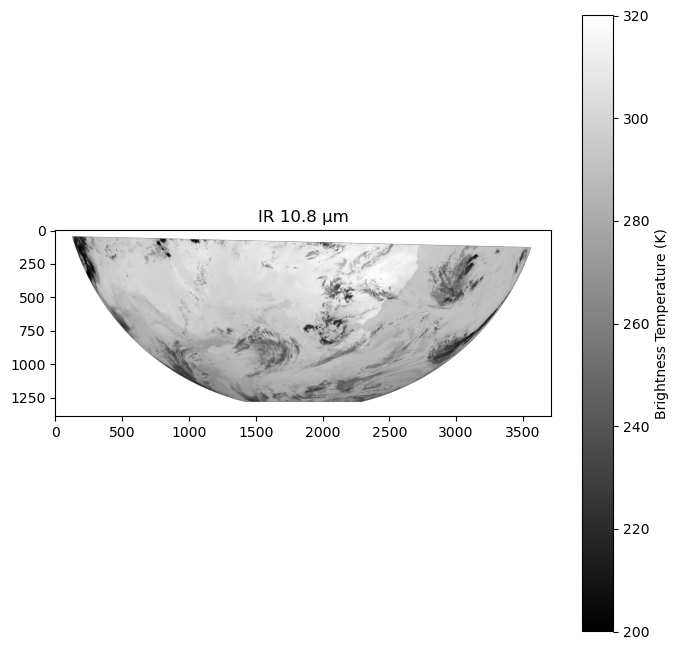

In [17]:
from satpy import Scene
import matplotlib.pyplot as plt

# Path to your .nat file
file = "msg_data/MSG3-SEVI-MSG15-0100-NA-20221006144918.412000000Z-NA.nat"

# Create scene
scn = Scene(reader="seviri_l1b_native", filenames=[file])

# See what channels are available
print(scn.available_dataset_names())

# Load a common IR channel (10.8 µm)
scn.load(['IR_108'])

# Get the data
data = scn['IR_108']

# Plot
plt.figure(figsize=(8,8))
plt.imshow(data, cmap='gray', vmin=200, vmax=320)
plt.colorbar(label="Brightness Temperature (K)")
plt.title("IR 10.8 µm")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..817.40717].


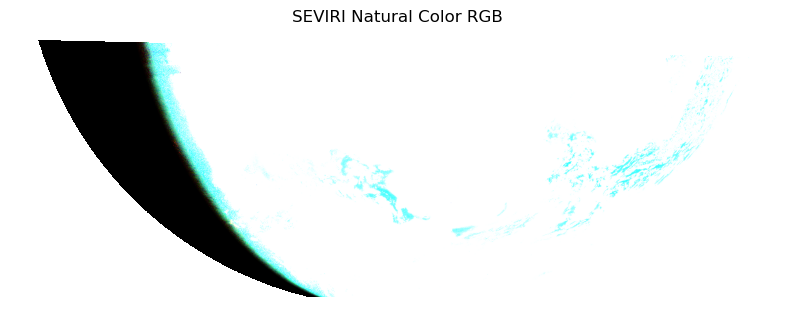

In [18]:
scn.load(['natural_color'])

rgb = scn['natural_color']

plt.figure(figsize=(10,8))
plt.imshow(rgb.transpose('y', 'x', 'bands'))
plt.axis('off')
plt.title("SEVIRI Natural Color RGB")
plt.show()